**GRADIENT DESCENT**

In [60]:
import numpy as np
from sklearn.datasets import make_regression

In [61]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=90,random_state=13)

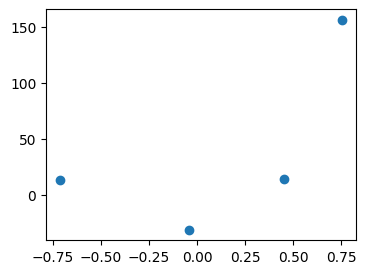

In [62]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.scatter(X,y)

**BY OLS**

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lr=LinearRegression()

In [65]:
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
lr.coef_
# slope (m)

array([80.53143548])

In [67]:
lr.intercept_
# b

np.float64(29.429586948524197)

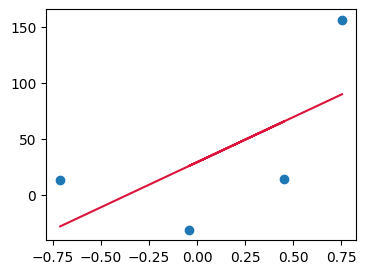

In [68]:
plt.figure(figsize=(4,3))
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='crimson')

**USING GRADIENT DESCENT**

*WE ASSUME OUR SLOPE M=80.53*

*LET'S ASSUME THE STARTING VALUE OF B=0*


In [69]:
y_pred=((80.53)*X+0).reshape(4)
# new line of model by taking b=0

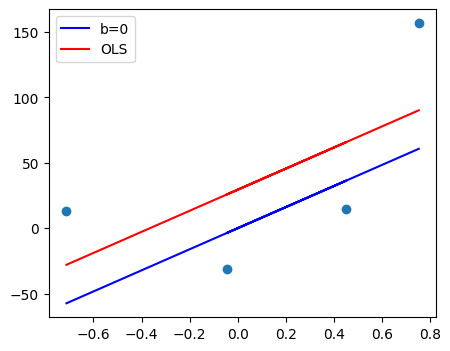

In [70]:
plt.figure(figsize=(5,4))
plt.scatter(X,y)
plt.plot(X,y_pred,color='blue',label='b=0')
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.legend()

In [71]:
m=80.53
b=0

loss_slope=-2*np.sum(y-m*X.ravel()-b)  # by differentiating the least square function
loss_slope

np.float64(-235.43798374471953)

In [72]:
# take learning rate =0.1
ler=0.1
step_s=loss_slope*ler
step_s


np.float64(-23.543798374471955)

In [73]:
# new intercept
b=b-step_s
b

# we jump from b=0 to b=23.54 but our actual intercept is 29.something

np.float64(23.543798374471955)

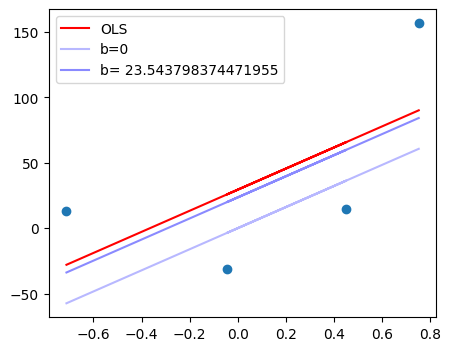

In [74]:
y_pred1=(80.53*X+b)
plt.figure(figsize=(5,4))
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#B8B8FF',label='b=0')
plt.plot(X,y_pred1,color='#8A8AFF',label='b= {}'.format(b))
plt.legend()

In [75]:
# again doing the same thing
loss_slope= -2 * np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-47.08759674894391)

In [76]:
step_s=loss_slope*ler
step_s

np.float64(-4.708759674894391)

In [77]:
b=b-step_s
b

np.float64(28.252558049366346)

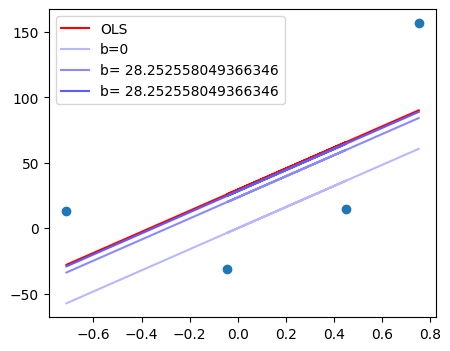

In [78]:
y_pred2=(80.53*X+b)
plt.figure(figsize=(5,4))
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#B8B8FF',label='b=0')
plt.plot(X,y_pred1,color='#8A8AFF',label='b= {}'.format(b))
plt.plot(X,y_pred2,color='#5C5CFF',label='b= {}'.format(b))
plt.legend()

In [79]:
# again doing the same thing
loss_slope= -2 * np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-9.417519349788762)

In [80]:
step_s=loss_slope*ler
step_s

np.float64(-0.9417519349788762)

In [ ]:
b=b-step_s
b

# we are close to our target

np.float64(29.19430998434522)

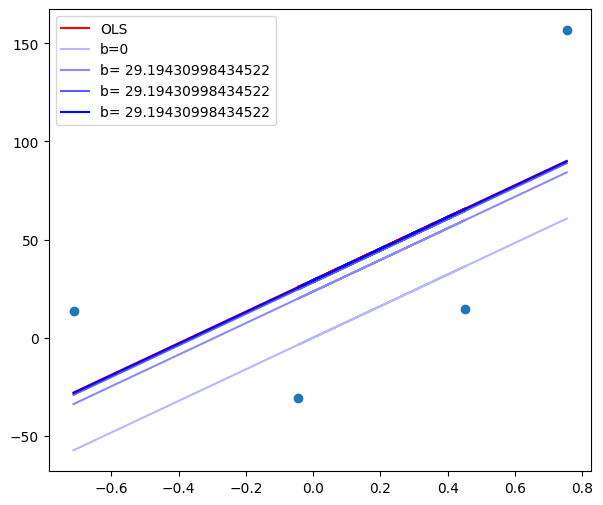

In [84]:
y_pred3=(80.53*X+b)
plt.figure(figsize=(7,6))
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#B8B8FF',label='b=0')
plt.plot(X,y_pred1,color='#8A8AFF',label='b= {}'.format(b))
plt.plot(X,y_pred2,color='#5C5CFF',label='b= {}'.format(b))
plt.plot(X,y_pred3,color='#0000FF',label='b= {}'.format(b))
plt.legend()

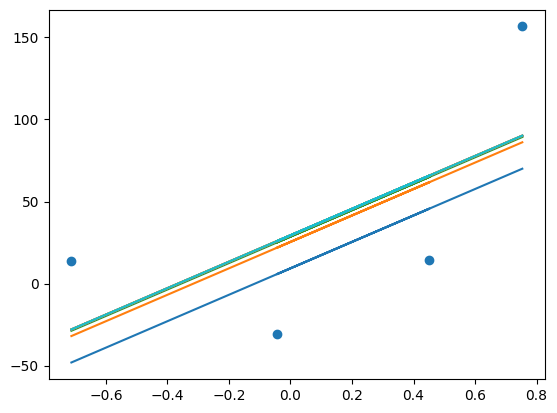

In [88]:
 # let's do it by loop till we find the value of  which gives us least error
# this time let's start with random b=-93
b-=93
m=80.53
ler=0.1
epochs=10  # we do the process 10 times
for i in range(epochs):
 loss_slope=-2*np.sum(y-m*X.ravel()-b)
 b=b-(ler*loss_slope)

 y_pred=m*X+b
 
 plt.plot(X,y_pred)
plt.scatter(X,y)